In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
df_movies = pd.read_csv('archive1/archive/movies_metadata.csv', sep=',', na_values=[''], quotechar='"')
df_ratings = pd.read_csv('archive1/archive/ratings_small.csv')

def safe_parse(val):
    if pd.isna(val) or val == '' or val == '[]' or val == '{}':
        return None
    try:
        return ast.literal_eval(val)
    except:
        try:
            return json.loads(val)
        except:
            return None

df_movies['id'] = pd.to_numeric(df_movies['id'], errors='coerce')
df_movies = df_movies.dropna(subset=['id']).copy()
df_movies['id'] = df_movies['id'].astype(int)

df_ratings['movieId'] = pd.to_numeric(df_ratings['movieId'], errors='coerce')
df_ratings = df_ratings.dropna(subset=['movieId']).copy()
df_ratings['movieId'] = df_ratings['movieId'].astype(int)

valid_movie_ids = df_ratings['movieId'].unique()
df_movies = df_movies[df_movies['id'].isin(valid_movie_ids)].copy()

df_movies['belongs_to_collection_parsed'] = df_movies['belongs_to_collection'].apply(safe_parse)
df_movies['genres_parsed'] = df_movies['genres'].apply(safe_parse)

df_movies['has_collection'] = df_movies['belongs_to_collection_parsed'].apply(
    lambda x: 1 if isinstance(x, dict) and x.get('name') else 0
)

df_movies['genre_list'] = df_movies['genres_parsed'].apply(
    lambda x: [g['name'] for g in x] if isinstance(x, list) else []
)

mlb = MultiLabelBinarizer()
genres_onehot = mlb.fit_transform(df_movies['genre_list'])
genres_df = pd.DataFrame(genres_onehot, columns=mlb.classes_, index=df_movies.index)

df_movies['vote_average'] = pd.to_numeric(df_movies['vote_average'], errors='coerce').fillna(0)
df_movies['vote_count'] = pd.to_numeric(df_movies['vote_count'], errors='coerce').fillna(0)

dense_features = pd.concat([
    df_movies[['has_collection', 'vote_average', 'vote_count']],
    genres_df
], axis=1)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16292\3851475733.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_movies = pd.read_csv('archive1/archive/movies_metadata.csv', sep=',', na_values=[''], quotechar='"')


In [6]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df_movies['overview'].fillna(''))

scaler = StandardScaler()
dense_scaled = scaler.fit_transform(dense_features)
dense_sparse = csr_matrix(dense_scaled)

X_combined = hstack([dense_sparse, tfidf_matrix])

print(f"Размерность матрицы признаков: {X_combined.shape}")

Размерность матрицы признаков: (2831, 5023)


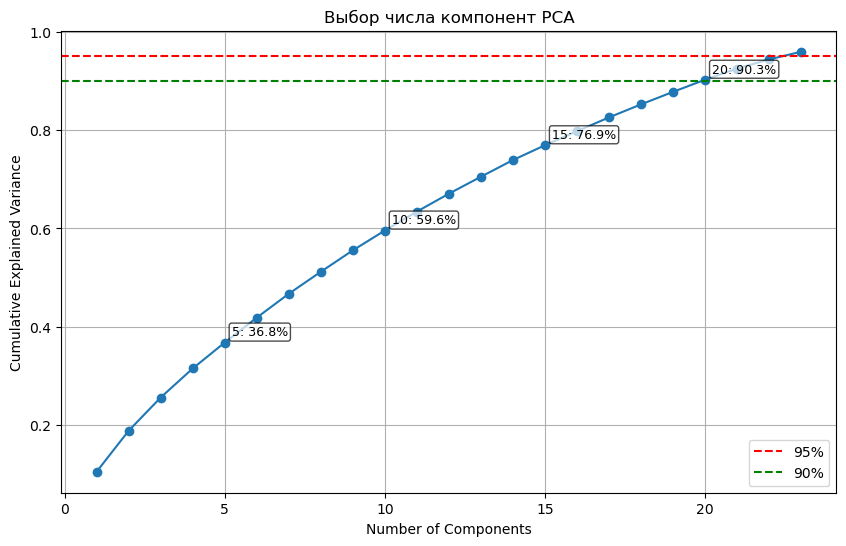

Для 95% дисперсии нужно 23 компонент
Для 90% дисперсии нужно 20 компонент


In [11]:
n_svd_components = 23
svd = TruncatedSVD(n_components=n_svd_components, random_state=42)
X_svd = svd.fit_transform(X_combined)

cum_var = np.cumsum(svd.explained_variance_ratio_)
components = np.arange(1, n_svd_components + 1)

plt.figure(figsize=(10,6))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.axhline(y=0.90, color='g', linestyle='--', label='90%')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Выбор числа компонент PCA')
plt.legend()
plt.grid(True)

step = 5
indices = range(step - 1, n_svd_components, step)
for i in indices:
    x = components[i]
    y = cum_var[i]
    label = f'{x}: {y:.1%}'
    plt.annotate(label,
                 xy=(x, y),
                 xytext=(5, 5),
                 textcoords='offset points',
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.show()

n_95 = np.argmax(cum_var >= 0.95) + 1
n_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Для 95% дисперсии нужно {n_95} компонент")
print(f"Для 90% дисперсии нужно {n_90} компонент")

K =  2 | Silhouette = 0.1473
K =  3 | Silhouette = 0.1604
K =  4 | Silhouette = 0.1331
K =  5 | Silhouette = 0.1389
K =  6 | Silhouette = 0.1265
K =  7 | Silhouette = 0.1320
K =  8 | Silhouette = 0.1394
K =  9 | Silhouette = 0.1553
K = 10 | Silhouette = 0.1625
K = 11 | Silhouette = 0.1712
K = 12 | Silhouette = 0.1846
K = 13 | Silhouette = 0.2079
K = 14 | Silhouette = 0.1956
K = 15 | Silhouette = 0.2097
K = 16 | Silhouette = 0.2216
K = 17 | Silhouette = 0.2274
K = 18 | Silhouette = 0.2314
K = 19 | Silhouette = 0.2332
K = 20 | Silhouette = 0.2291
K = 21 | Silhouette = 0.2289
K = 22 | Silhouette = 0.2450
K = 23 | Silhouette = 0.2495

Оптимальное K = 23 (силуэт = 0.2495)


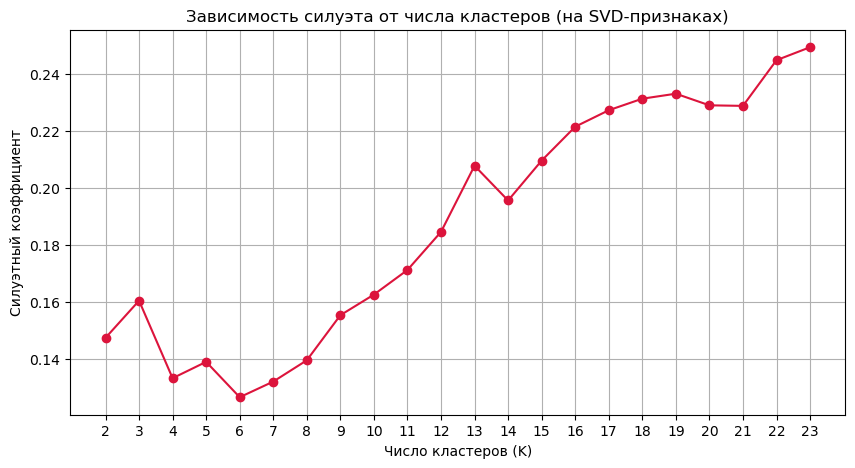

In [13]:
sample_size = min(5000, X_svd.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(X_svd.shape[0], size=sample_size, replace=False)
X_sample = X_svd[sample_idx]

K_range = range(2, 24)
silhouette_scores = []
best_k = None
best_score = -1

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_svd)
    labels_sample = kmeans.predict(X_sample)
    score = silhouette_score(X_sample, labels_sample)
    silhouette_scores.append(score)
    print(f"K = {k:2d} | Silhouette = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nОптимальное K = {best_k} (силуэт = {best_score:.4f})")

plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, marker='o', color='crimson')
plt.xlabel('Число кластеров (K)')
plt.ylabel('Силуэтный коэффициент')
plt.title('Зависимость силуэта от числа кластеров (на SVD-признаках)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

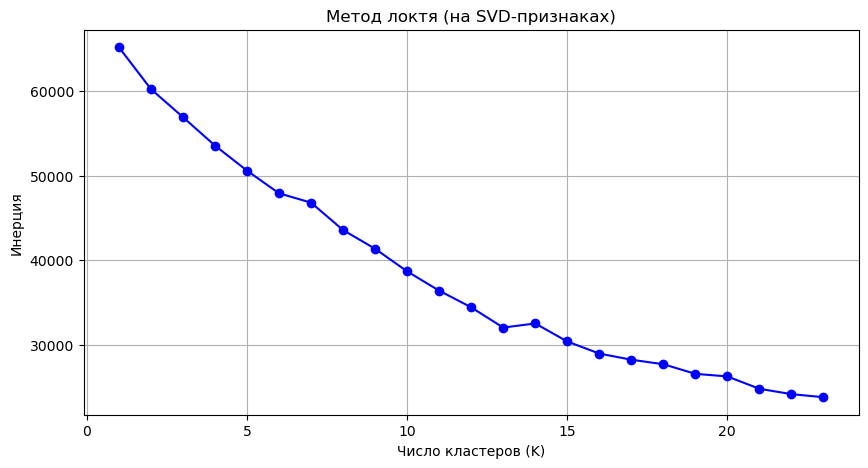

In [14]:
inertia = []
K_range_inertia = range(1, 24)
for k in K_range_inertia:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_svd)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range_inertia, inertia, marker='o', color='blue')
plt.xlabel('Число кластеров (K)')
plt.ylabel('Инерция')
plt.title('Метод локтя (на SVD-признаках)')
plt.grid(True)
plt.show()

In [ ]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
cluster_labels = final_kmeans.fit_predict(X_svd)
df_movies['cluster'] = cluster_labels

print("\nРаспределение объектов по кластерам:")
print(df_movies['cluster'].value_counts().sort_index())

In [ ]:
numeric_cols = ['vote_average', 'vote_count']
numeric_cols = [col for col in numeric_cols if col in df_movies.columns]

cluster_profile_mean = df_movies.groupby('cluster')[numeric_cols].mean()
cluster_profile_median = df_movies.groupby('cluster')[numeric_cols].median()

print("\nСредние значения числовых признаков по кластерам:")
print(cluster_profile_mean.round(2))

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile_mean.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних значений числовых признаков по кластерам')
plt.show()

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_movies, x='cluster', y=col)
    plt.title(f'Распределение {col} по кластерам')
    plt.show()

cat_features = ['has_collection'] + list(genres_df.columns)
cluster_cat_mean = df_movies.groupby('cluster')[cat_features].mean()
print("\nСредние доли категориальных признаков по кластерам:")
print(cluster_cat_mean.round(3))

plt.figure(figsize=(16, 12))
sns.heatmap(cluster_cat_mean.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних долей категориальных признаков по кластерам')
plt.show()

In [ ]:
pca_df = pd.DataFrame({
    'SVD1': X_svd[:, 0],
    'SVD2': X_svd[:, 1],
    'Cluster': cluster_labels.astype(str)
})

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=pca_df,
    x='SVD1', y='SVD2',
    hue='Cluster',
    palette='viridis',
    alpha=0.6,
    edgecolor=None,
    s=20
)
plt.title(f'Визуализация кластеров K-Means (K={best_k}) на первых двух SVD-компонентах', fontsize=16)
plt.xlabel(f'SVD компонента 1 (объяснённая дисперсия: {svd.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'SVD компонента 2 (объяснённая дисперсия: {svd.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()